# Multidimensional GBM Monte Carlo for Discounted Cash Flow

This notebook is ordered so you can plug in:

1. your stochastic drivers
2. your covariance matrix
3. your discounted cash flow function

The core idea is:

- simulate correlated Brownian shocks using the covariance matrix
- evolve all stochastic drivers jointly under a multidimensional GBM
- apply your discounted cash flow function to each simulated path


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Define simulation inputs

Keep all user-editable assumptions in one place.


In [32]:
# Basic Monte Carlo settings
n_assets = 4
n_sims = 10_000
n_steps = 18
T = 18.0
dt = T / n_steps

# Keep the driver order fixed throughout the notebook
asset_names = [
    "price_of_ibap",
    "ibap_throughput",
    "price_of_HF",
    "HF_throughput",
]

# Initial values S(0)
S0 = np.array([
    7.17,
    6629568,
    1.50,
    3376704,
])

# Annualized drifts mu
mu = np.array([
    1,
    1,
    1,
    1,
])

raw_material_cost = 24684382
inflation = 0.05
discount_rate = 0.15

# Annualized covariance matrix of the GBM drivers
# Replace this with your own covariance matrix
cov_matrix = np.array([
    [0.017536, 0, 0.001032, 0],
    [0, 0.01, 0, 0],
    [0.001032, 0, 0.000804, 0],
    [0, 0, 0, 0.1],
], dtype=float)

assert len(S0) == n_assets
assert len(mu) == n_assets
assert cov_matrix.shape == (n_assets, n_assets)

## 2. Validate covariance matrix

This helps catch dimension errors and non-positive semidefinite inputs early.


In [33]:
def validate_covariance_matrix(cov):
    cov = np.asarray(cov, dtype=float)

    if cov.ndim != 2 or cov.shape[0] != cov.shape[1]:
        raise ValueError("cov_matrix must be square.")

    if not np.allclose(cov, cov.T, atol=1e-10):
        raise ValueError("cov_matrix must be symmetric.")

    eigenvalues = np.linalg.eigvalsh(cov)
    if np.min(eigenvalues) < -1e-10:
        raise ValueError("cov_matrix must be positive semidefinite.")

    return eigenvalues


eigenvalues = validate_covariance_matrix(cov_matrix)
vols = np.sqrt(np.diag(cov_matrix))
corr_matrix = cov_matrix / np.outer(vols, vols)

print("Eigenvalues:", eigenvalues)
print("Volatilities:", vols)
print("Correlation matrix:\n", corr_matrix)

Eigenvalues: [0.00074059 0.01       0.01759941 0.1       ]
Volatilities: [0.13242356 0.1        0.02835489 0.31622777]
Correlation matrix:
 [[1.         0.         0.27484409 0.        ]
 [0.         1.         0.         0.        ]
 [0.27484409 0.         1.         0.        ]
 [0.         0.         0.         1.        ]]


## 3. Multidimensional GBM simulator

The update rule is:

$$S_{t+\Delta t}^{(i)} = S_t^{(i)} \exp\left((\mu_i - 0.5\sigma_i^2)\Delta t + \Delta W_i\right)$$

where the correlated increment vector satisfies:

$$\Delta W \sim \mathcal{N}(0, \Sigma \Delta t)$$

and `cov_matrix = Sigma`.


In [34]:
def simulate_multidim_gbm(S0, mu, cov_matrix, asset_names, T, n_steps, n_sims, random_seed=42):
    S0 = np.asarray(S0, dtype=float)
    mu = np.asarray(mu, dtype=float)
    cov_matrix = np.asarray(cov_matrix, dtype=float)
    asset_names = list(asset_names)

    n_assets = len(S0)
    dt = T / n_steps

    if len(mu) != n_assets:
        raise ValueError("mu must have the same length as S0.")

    if len(asset_names) != n_assets:
        raise ValueError("asset_names must have the same length as S0.")

    validate_covariance_matrix(cov_matrix)

    if cov_matrix.shape != (n_assets, n_assets):
        raise ValueError("cov_matrix dimensions must match the number of stochastic drivers.")

    rng = np.random.default_rng(random_seed)

    # Use an eigenvalue factorization to remain stable even if the matrix
    # is only positive semidefinite.
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    cov_sqrt = eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T

    z = rng.normal(size=(n_sims, n_steps, n_assets))
    dW = np.sqrt(dt) * np.einsum("tka,ab->tkb", z, cov_sqrt)

    variances = np.diag(cov_matrix)
    drift_term = (mu - 0.5 * variances) * dt

    log_returns = drift_term[None, None, :] + dW

    log_paths = np.zeros((n_sims, n_steps + 1, n_assets), dtype=float)
    log_paths[:, 0, :] = np.log(S0)
    log_paths[:, 1:, :] = np.log(S0)[None, None, :] + np.cumsum(log_returns, axis=1)

    paths = np.exp(log_paths)

    return {
        name: paths[:, :, idx]
        for idx, name in enumerate(asset_names)
    }

## 4. Define the discounted cash flow function

The simulator now returns a dictionary whose keys are your stochastic driver names.

For example:

- `simulated_paths["price_of_ibap"]`
- `simulated_paths["ibap_throughput"]`
- `simulated_paths["price_of_HF"]`
- `simulated_paths["HF_throughput"]`


In [35]:
def calculate_discounted_cash_flows(simulated_paths, raw_material_cost, inflation, discount_rate):
    price_of_ibap = simulated_paths["price_of_ibap"]
    ibap_throughput = simulated_paths["ibap_throughput"]
    price_of_HF = simulated_paths["price_of_HF"]
    HF_throughput = simulated_paths["HF_throughput"]

    t = np.arange(price_of_ibap.shape[1])

    revenue = price_of_ibap * ibap_throughput + price_of_HF * HF_throughput
    cost = raw_material_cost * (1 + inflation) ** t
    net_cash_flow = revenue - cost
    discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** t

    return discounted_cash_flow


def total_present_value(simulated_paths, raw_material_cost, inflation, discount_rate):
    discounted_cash_flows = calculate_discounted_cash_flows(
        simulated_paths,
        raw_material_cost=raw_material_cost,
        inflation=inflation,
        discount_rate=discount_rate,
    )
    return discounted_cash_flows.sum(axis=1)

## 5. Run the simulation


In [36]:
simulated_paths = simulate_multidim_gbm(
    S0=S0,
    mu=mu,
    cov_matrix=cov_matrix,
    asset_names=asset_names,
    T=T,
    n_steps=n_steps,
    n_sims=n_sims,
    random_seed=42,
)

discounted_cash_flows = calculate_discounted_cash_flows(
    simulated_paths,
    raw_material_cost=raw_material_cost,
    inflation=inflation,
    discount_rate=discount_rate,
)

results = total_present_value(
    simulated_paths,
    raw_material_cost=raw_material_cost,
    inflation=inflation,
    discount_rate=discount_rate,
)

for name in asset_names:
    print(name, simulated_paths[name].shape)
print("discounted_cash_flows shape:", discounted_cash_flows.shape)
print("results shape:", results.shape)

price_of_ibap (10000, 19)
ibap_throughput (10000, 19)
price_of_HF (10000, 19)
HF_throughput (10000, 19)
discounted_cash_flows shape: (10000, 19)
results shape: (10000,)


In [37]:
# # Checks delete after
# print(results[:5])
# print(discounted_cash_flows.head(5))
# print(simulated_paths.head(5))

## 6. Summarize results


In [38]:
summary = pd.Series(results).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
summary

count    1.000000e+04
mean     2.173970e+22
std      1.624926e+22
min      1.680298e+21
1%       3.946528e+21
5%       6.008085e+21
50%      1.737178e+22
95%      5.192213e+22
99%      8.232024e+22
max      2.868088e+23
dtype: float64

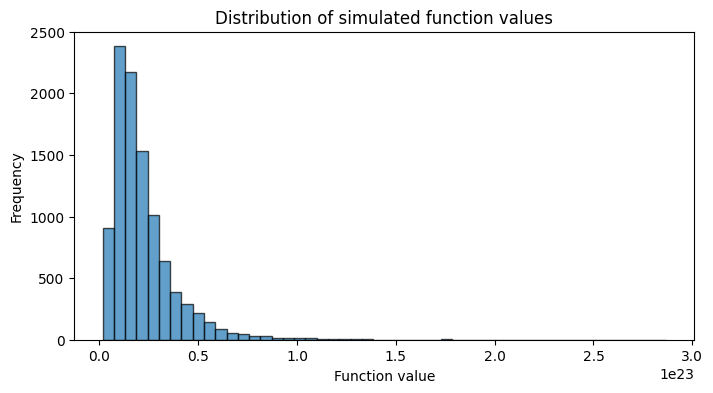

In [39]:
plt.figure(figsize=(8, 4))
plt.hist(results, bins=50, edgecolor="black", alpha=0.7)
plt.title("Distribution of simulated function values")
plt.xlabel("Function value")
plt.ylabel("Frequency")
plt.show()

## 7. Inspect a few simulated paths


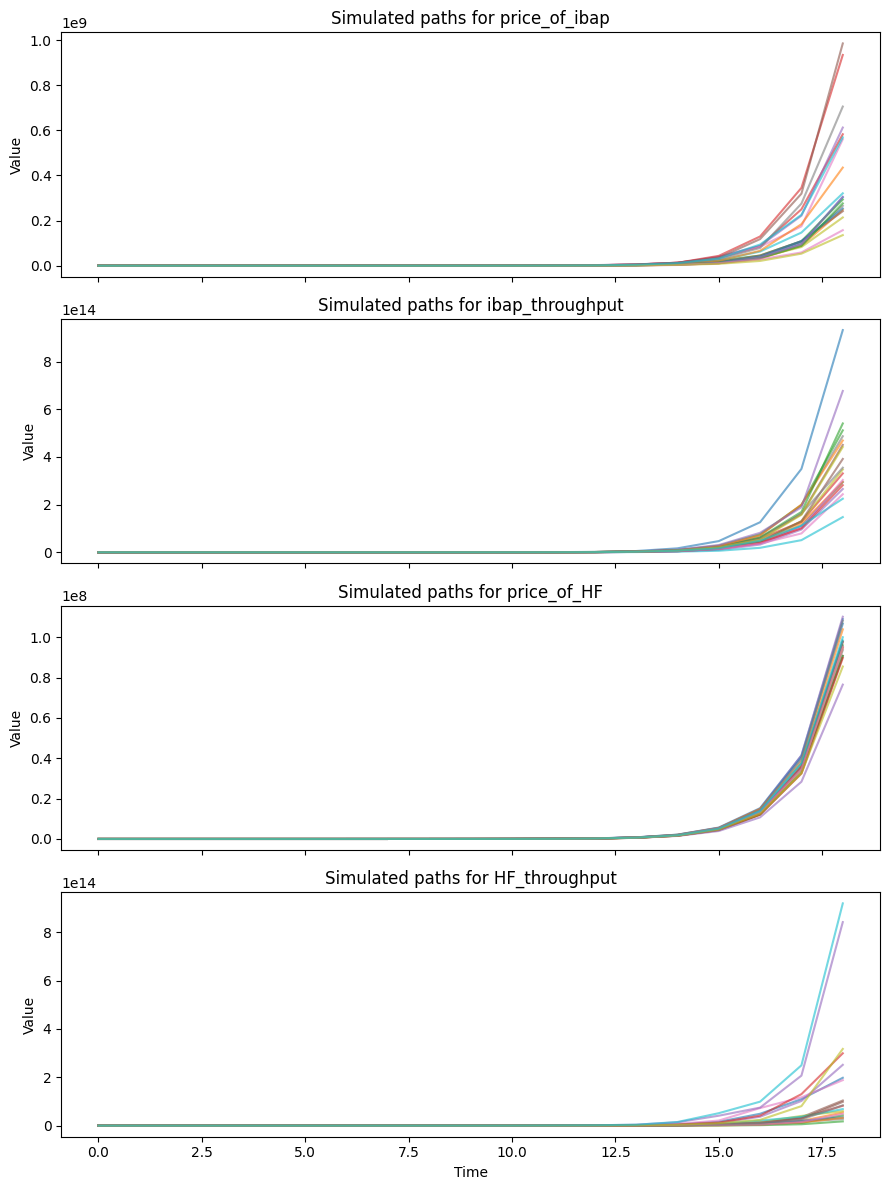

In [40]:
time_grid = np.linspace(0, T, n_steps + 1)

fig, axes = plt.subplots(n_assets, 1, figsize=(9, 3 * n_assets), sharex=True)
if n_assets == 1:
    axes = [axes]

for asset_idx, ax in enumerate(axes):
    driver_name = asset_names[asset_idx]
    for sim_idx in range(min(20, n_sims)):
        ax.plot(time_grid, simulated_paths[driver_name][sim_idx, :], alpha=0.6)
    ax.set_title(f"Simulated paths for {driver_name}")
    ax.set_ylabel("Value")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Notes

- If your covariance matrix is estimated from historical log returns, it can be used directly as `cov_matrix`.
- If you instead have a correlation matrix and separate volatilities, build covariance as:
  `cov_matrix = np.outer(vols, vols) * corr_matrix`
- This version returns a dictionary of simulated paths keyed by driver name, so the DCF formula reads more naturally.
- If you prefer, I can also convert the simulator back to returning a single 3D NumPy array.
